In [1]:
import warnings
warnings.filterwarnings("ignore") ## Dọn dẹp và làm sạch màn hình
import pandas as pd ## Thư viện đọc file dữ liệu
import numpy as np ## Thư viện tính toán
import seaborn as sns ## Vẽ các đồ thị
sns.set(style='darkgrid') ## Thiết lập kiểu đồ thị
import matplotlib.pyplot as plt ## Vẽ biểu đồ
%matplotlib inline
import missingno as msno ## Trực quan hóa các giá trị bị thiếu
import os
import glob
import sklearn as sk
import time
seconds = time.time()
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support, precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from xgboost import plot_importance
import joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
## Load dữ liệu chuẩn bị train
train_df = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/train_smote_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/BTL_TSL_MR/test_data.csv')
X_train = train_df.drop(columns=[train_df.columns[-1]])
y_train = train_df[train_df.columns[-1]]
X_test = test_df.drop(columns=[test_df.columns[-1]])
y_test = test_df[test_df.columns[-1]]
print(f"Sẵn sàng huấn luyện với {X_train.shape[0]} mẫu cân bằng!")

Sẵn sàng huấn luyện với 1000000 mẫu cân bằng!


In [4]:
## Khai báo các model train
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, tree_method='hist'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Naive Bayes": GaussianNB()
}

In [5]:
## Bắt đầu huấn luyện và so sánh kết quả 6 mô hình với nhau
## Tạo một danh sách rỗng để lưu kết quả chấm điểm
results = []
for name, model in models.items():
    print(f"\nĐang train mô hình: {name}...")
    start_time = time.time()
    ## Học trên tập Train
    model.fit(X_train, y_train)
    train_time = round(time.time() - start_time, 2)
    ## Làm bài thi trên tập Test
    y_pred = model.predict(X_test)
    ## Chấm điểm
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision_weighted = precision_score(y_test, y_pred, average='weighted')
    recall_weighted = recall_score(y_test, y_pred, average='weighted')
    print(f"Thời gian train: {train_time}s | Accuracy: {acc*100:.2f}% | F1-Score: {f1*100:.2f}% | Precision: {precision_weighted*100:.2f}% | Recall: {recall_weighted*100:.2f}%")
    ## Lưu bảng điểm vào danh sách
    results.append({
        "Model": name,
        "Accuracy (%)": acc * 100,
        "F1-Score (%)": f1 * 100,
        "Precision (%)": precision_weighted * 100,
        "Recall (%)": recall_weighted * 100,
        "Train Time (s)": train_time
    })


Đang train mô hình: Random Forest...
Thời gian train: 198.44s | Accuracy: 98.50% | F1-Score: 95.74% | Precision: 98.61% | Recall: 98.50%

Đang train mô hình: Extra Trees...
Thời gian train: 86.84s | Accuracy: 98.51% | F1-Score: 95.76% | Precision: 98.62% | Recall: 98.51%

Đang train mô hình: XGBoost...
Thời gian train: 11.58s | Accuracy: 98.53% | F1-Score: 95.82% | Precision: 98.64% | Recall: 98.53%

Đang train mô hình: Decision Tree...
Thời gian train: 14.77s | Accuracy: 98.49% | F1-Score: 95.71% | Precision: 98.60% | Recall: 98.49%

Đang train mô hình: Logistic Regression...
Thời gian train: 110.05s | Accuracy: 89.18% | F1-Score: 65.75% | Precision: 88.71% | Recall: 89.18%

Đang train mô hình: Naive Bayes...
Thời gian train: 0.48s | Accuracy: 34.73% | F1-Score: 33.54% | Precision: 84.69% | Recall: 34.73%


| Model               |   Accuracy (%) |   F1-Score (%) |   Precision (%) |   Recall (%) |   Train Time (s) |
|:--------------------|---------------:|---------------:|----------------:|-------------:|-----------------:|
| Random Forest       |        98.502  |        95.7433 |         98.6149 |      98.502  |           198.44 |
| Extra Trees         |        98.5097 |        95.7648 |         98.622  |      98.5097 |            86.84 |
| XGBoost             |        98.5305 |        95.8196 |         98.6377 |      98.5305 |            11.58 |
| Decision Tree       |        98.4899 |        95.7104 |         98.6047 |      98.4899 |            14.77 |
| Logistic Regression |        89.1824 |        65.7534 |         88.708  |      89.1824 |           110.05 |
| Naive Bayes         |        34.7279 |        33.5387 |         84.6884 |      34.7279 |             0.48 |


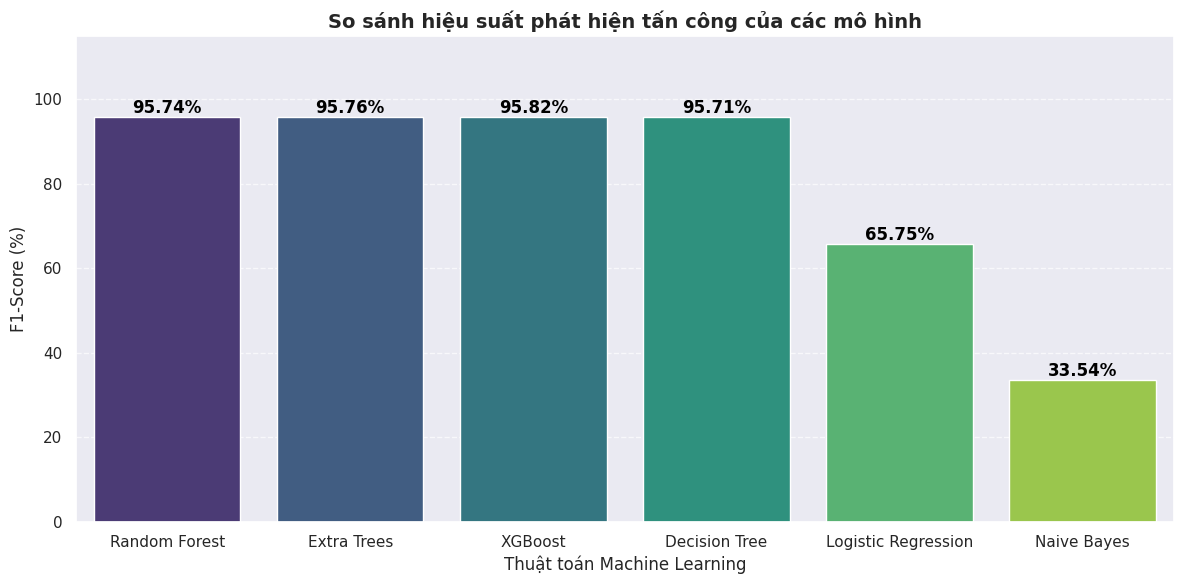

In [6]:
## Lập bảng và vẽ biểu đồ
## Biến danh sách kết quả thành bảng DataFrame
results_df = pd.DataFrame(results)
print(results_df.to_markdown(index=False))
## Vẽ biểu đồ cột so sánh điểm F1-Score
plt.figure(figsize=(12, 6))
## Dùng hue và legend=False để tránh cảnh báo của Seaborn bản mới
sns.barplot(x='Model', y='F1-Score (%)', data=results_df, hue='Model', palette='viridis', legend=False)
## Gắn con số phần trăm lên đỉnh từng cột cho đẹp
for index, row in results_df.iterrows():
    plt.text(index, row['F1-Score (%)'] + 1, f"{row['F1-Score (%)']:.2f}%", color='black', ha="center", fontweight='bold')
plt.ylim(0, 115)
plt.title('So sánh hiệu suất phát hiện tấn công của các mô hình', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score (%)', fontsize=12)
plt.xlabel('Thuật toán Machine Learning', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
## Đóng gói mô hình
best_model = models["XGBoost"]
model_path = '/content/drive/MyDrive/BTL_TSL_MR/Best_Model_Final.pkl'
joblib.dump(best_model, model_path)
print(f"XUẤT MODEL THÀNH CÔNG!")
print(f"File AI để nhúng vào OpenNMS đang nằm tại: {model_path}")

XUẤT MODEL THÀNH CÔNG!
File AI để nhúng vào OpenNMS đang nằm tại: /content/drive/MyDrive/BTL_TSL_MR/Best_Model_Final.pkl


In [8]:
import joblib
model = joblib.load('/content/drive/MyDrive/BTL_TSL_MR/Best_Model_Final.pkl')
# Nếu là XGBoost, nó thường lưu tên feature trong attribute này:
print(model.get_booster().feature_names)

['Bwd Packet Length Std', 'Bwd Packet Length Mean', 'Average Packet Size', 'Max Packet Length', 'Packet Length Variance', 'Bwd Packet Length Max', 'Avg Bwd Segment Size', 'Packet Length Mean', 'Destination Port', 'Packet Length Std', 'Total Length of Bwd Packets', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Fwd Packets', 'act_data_pkt_fwd', 'Fwd Packet Length Max', 'Avg Fwd Segment Size', 'Subflow Bwd Bytes', 'ACK Flag Count']
